<img src="imgs\banner_fcd.jpg" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Análisis Multivariado</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2025/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

In [1]:
# Solicitar datos al estudiante
nombre = input("Ingresa tu nombre completo: ")
correo = input("Ingresa tu correo electrónico: ")

# Mostrar los datos ingresados
print("\nResumen de datos ingresados:")
print(f"Nombre: {nombre}")
print(f"Correo electrónico: {correo}")


Resumen de datos ingresados:
Nombre: Santiago Correa Marulanda
Correo electrónico: santiago.correa7@udea.edu.co


## <span style="color:black;"><strong>Parte 3: Análisis Multivariado</strong></span>

### <span style="color:#2F749F;"><strong>Ejercicio1: Análisis de componentes principales</strong></span>

A partir de un conjunto de datos real sobre pingüinos antárticos, realiza un análisis multivariado utilizando PCA para reducir la dimensionalidad y visualizar agrupamientos por especie.

1. Carga el conjunto de datos penguins desde la librería seaborn `load_dataset("penguins")`.
2. Selecciona las siguientes variables morfológicas para el análisis:
   - 'bill_length_mm'
   - 'bill_depth_mm'
   - 'flipper_length_mm'
   - 'body_mass_g'
3. Estandariza las variables seleccionadas usando StandardScaler.
4. Aplica PCA()
5. Imprime las ecuaciones que obtuviste para el número de componentes que utilizaste
6. Grafica los resultados en un plano bidimensional (PC1 vs PC2), diferenciando por especie (ver imagen).
7. Interpreta visualmente qué especies se agrupan o separan mejor en el espacio reducido.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

penguins = sns.load_dataset("penguins")
df = penguins.select_dtypes(include='number')
df['species'] = penguins['species']
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   bill_depth_mm      342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   species            344 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [2]:
df.dropna(inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     342 non-null    float64
 1   bill_depth_mm      342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   species            342 non-null    object 
dtypes: float64(4), object(1)
memory usage: 16.0+ KB


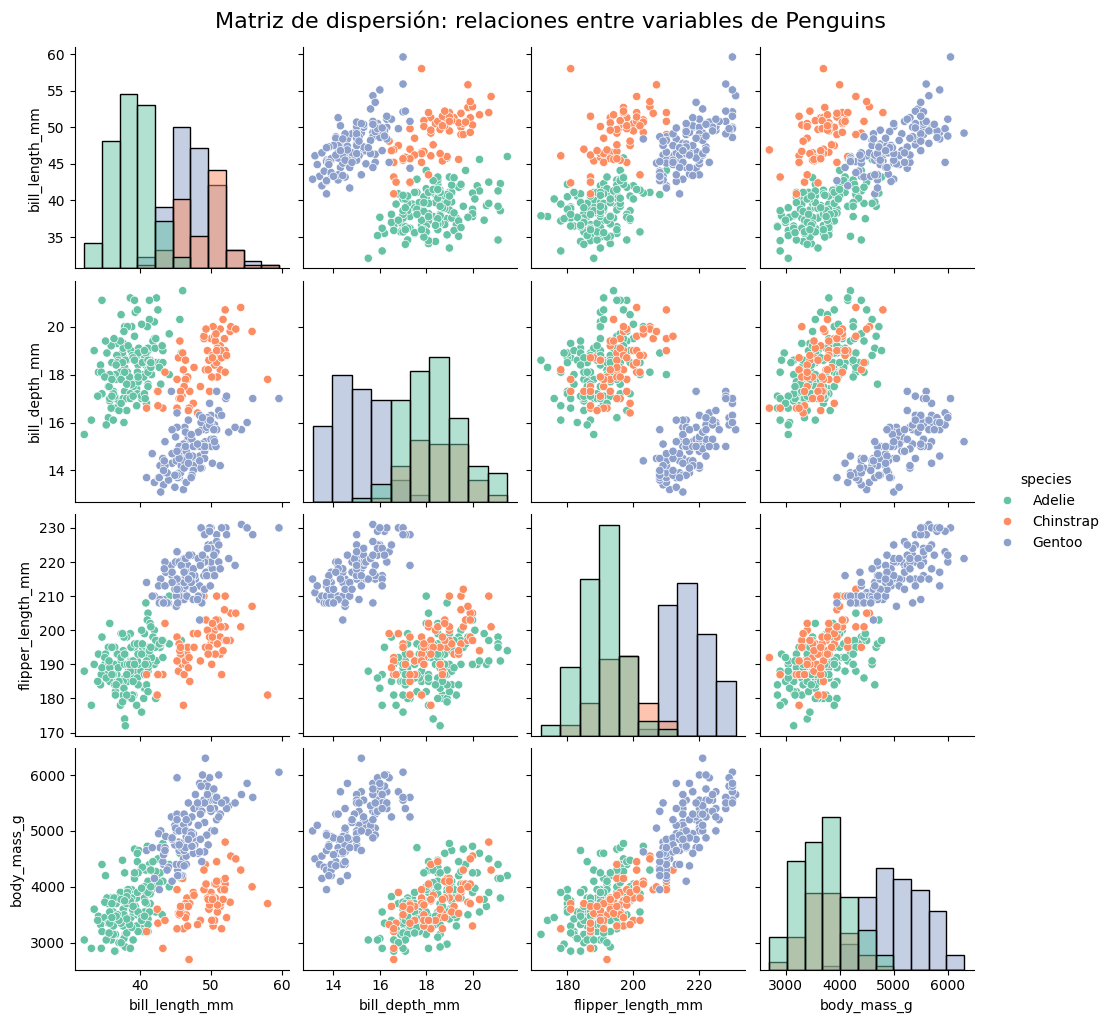

In [3]:
# Estandarizar variables numéricas
scaler = StandardScaler()
X_std = scaler.fit_transform(df.select_dtypes(include='number'))

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)
df.head()
sns.pairplot(df, hue='species', palette='Set2', diag_kind='hist', corner=False)
plt.suptitle('Matriz de dispersión: relaciones entre variables de Penguins', fontsize=16, y=1.02)
plt.show()

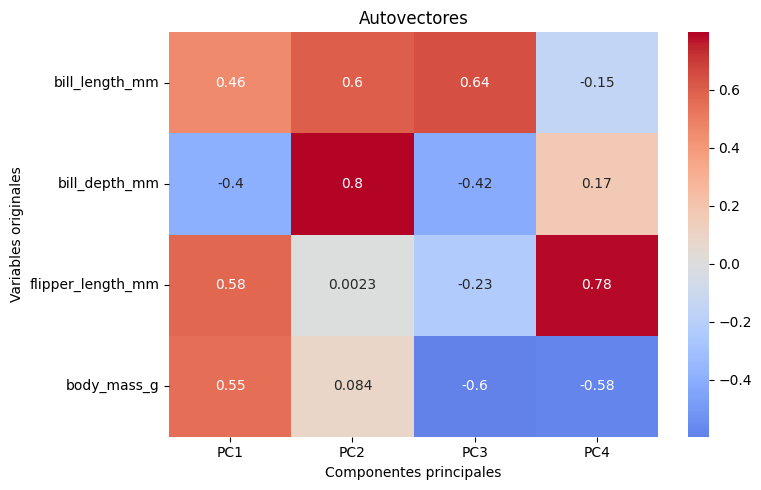

Ecuaciones de los componentes principales:

PC1 = 0.455·'bill_length_mm' + -0.4·'bill_depth_mm' + 0.576·'flipper_length_mm' + 0.548·'body_mass_g'
PC2 = 0.597·'bill_length_mm' + 0.798·'bill_depth_mm' + 0.002·'flipper_length_mm' + 0.084·'body_mass_g'
PC3 = 0.644·'bill_length_mm' + -0.418·'bill_depth_mm' + -0.232·'flipper_length_mm' + -0.597·'body_mass_g'
PC4 = -0.146·'bill_length_mm' + 0.168·'bill_depth_mm' + 0.784·'flipper_length_mm' + -0.58·'body_mass_g'


In [4]:
# Matriz de componentes


componentes = pd.DataFrame(pca.components_.T, 
                           columns=[f'PC{i+1}' for i in range(len(df.select_dtypes(include='number').columns))], 
                           index=df.select_dtypes(include='number').columns)

# 📐 Visualización de autovectores
plt.figure(figsize=(8, 5))
sns.heatmap(componentes, annot=True, cmap='coolwarm', center=0)
plt.title('Autovectores')
plt.ylabel('Variables originales')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

print("Ecuaciones de los componentes principales:\n")
for i, comp in enumerate(componentes.columns):
    pesos = pca.components_[i]
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{df.select_dtypes(include='number').columns[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}")

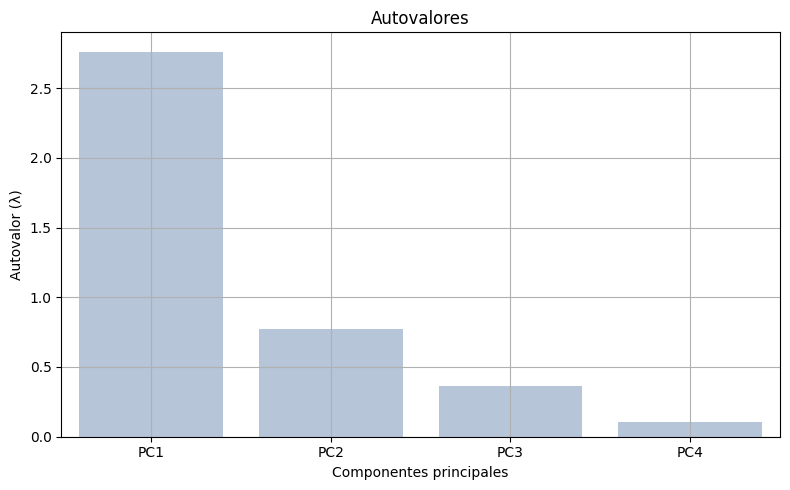

In [5]:
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes = [f'PC{i+1}' for i in range(len(PVE))]

# DataFrame para visualización
df_varianza = pd.DataFrame({
    'Componente': componentes,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

plt.figure(figsize=(8, 5))
sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
plt.title('Autovalores')
plt.ylabel('Autovalor (λ)')
plt.xlabel('Componentes principales')
plt.grid(True)
plt.tight_layout()
plt.show()

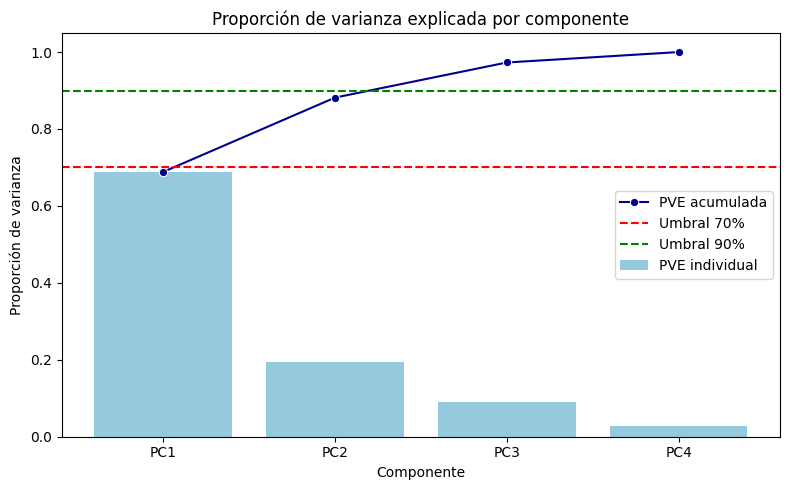

In [6]:
# Proporción de varianza explicada
plt.figure(figsize=(8, 5))
sns.barplot(x='Componente', y='PVE', data=df_varianza, color='skyblue', label='PVE individual')
sns.lineplot(x='Componente', y='PVE acumulada', data=df_varianza, marker='o', color='darkblue', label='PVE acumulada')
plt.axhline(0.7, color='red', linestyle='--', label='Umbral 70%')
plt.axhline(0.9, color='green', linestyle='--', label='Umbral 90%')
plt.title('Proporción de varianza explicada por componente')
plt.ylabel('Proporción de varianza')
plt.legend()
plt.tight_layout()
plt.show()

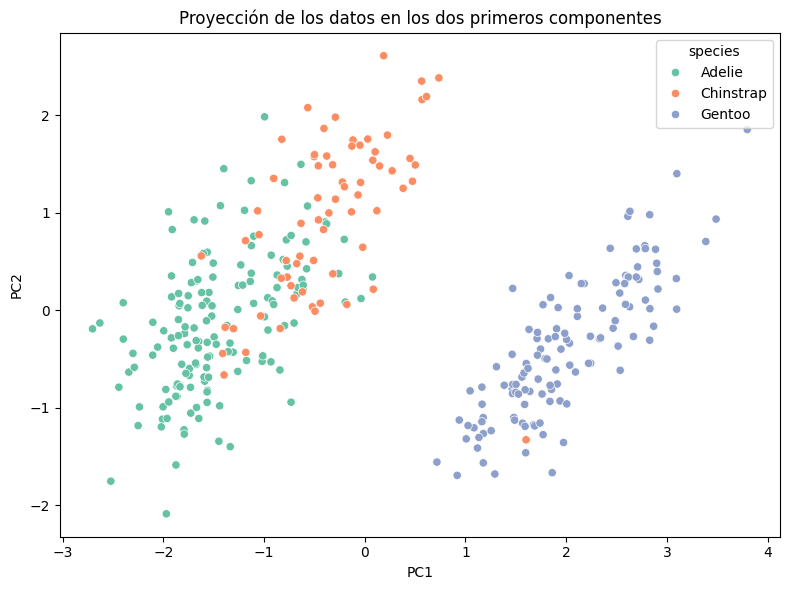

In [7]:
df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(PVE))])
df_pca['species'] = df['species']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='species', palette='Set2')
plt.title('Proyección de los datos en los dos primeros componentes')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

#### Interpreta visualmente qué especies se agrupan o separan mejor en el espacio reducido.

La especie Gentoo se logra diferenciar mucho más que las especies Adelie y Chinstrap, estas ultimas dos son más complejas de separar ya que se puede observar que se agrupan

### <span style="color:#2F749F;"><strong>Ejercicio 2: Regresión Lineal Múltiple</strong></span>  

A partir de un conjunto de datos real sobre diamantes, realiza un análisis de regresión lineal múltiple para predecir el precio en función de variables numéricas relacionadas con sus características físicas.  

1. Carga el conjunto de datos `diamonds` desde la librería seaborn `load_dataset("diamonds")`.  
2. Selecciona las siguientes variables predictoras para el análisis:  
   - `carat`  
   - `depth`  
   - `table`  
   - `x`  
   - `y`  
   - `z`  
3. Define como variable respuesta el precio (`price`).  
4. Divide los datos en entrenamiento y prueba para validar el modelo.  
5. Ajusta un modelo de **Regresión Lineal Múltiple** usando `statsmodels.OLS()`.  
6. Imprime el resumen del modelo (coeficientes, significancia, R² ajustado, etc.).  
7. Evalúa el desempeño del modelo con métricas de ajuste como **RMSE** y **R²** en el conjunto de prueba.  
8. Grafica los valores reales vs. los valores predichos del precio para interpretar la calidad del ajuste.  


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


diamonds = sns.load_dataset("diamonds")
diamonds.dropna(inplace=True)
diamonds.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
X = diamonds[["carat","depth","table","x","y","z"]]
Y = diamonds["price"]


In [4]:
from sklearn.model_selection import train_test_split

X_const = sm.add_constant(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_const, Y, test_size= 0.33, random_state=42)

model = sm.OLS(Y_train, X_train).fit()
pred = model.predict(X_test)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                 3.677e+04
Date:                Thu, 11 Sep 2025   Prob (F-statistic):               0.00
Time:                        10:14:41   Log-Likelihood:            -3.1566e+05
No. Observations:               36139   AIC:                         6.313e+05
Df Residuals:                   36132   BIC:                         6.314e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.074e+04    542.111     38.257      0.0

In [5]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test, pred)
rmse = np.sqrt(mse)

print(f"RMSE: {rmse:.2f}")

RMSE: 1483.33


### Interpretación $R^2$ y $R_a^2$

**$R^2$: El 85.9% de los datos es explicado por el modelo, es decir, explicados por las variables carat, depth, table, x, y, z**

**RMSE: En promedio, las predicciones del modelo se desvian aproximadamente 1483.33 USD**

In [53]:
print(f"\n\tPredicciones: {pred}")



	Predicciones: 1388       200.610316
50052     2365.463278
41645     1057.844786
42377     1234.149705
17244    10033.056143
             ...     
31474      748.998282
22112     7671.944962
134       3287.249862
31314      627.814023
44272     1800.389557
Length: 17801, dtype: float64



	Prueba de Durbin Watson: 1.989


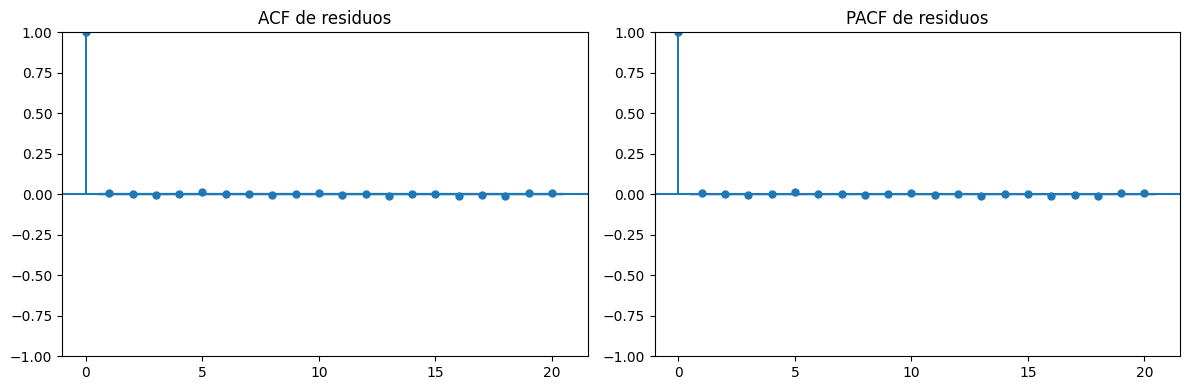

In [58]:
from statsmodels.stats.stattools import durbin_watson

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

residuo = model.resid

dw = durbin_watson(residuo)
print(f"\n\tPrueba de Durbin Watson: {dw:.3f}")

# gráficos de ACF (Autocorrelation Function) y PACF (Partial Autocorrelation Function)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuo, ax=axes[0], lags=20)
axes[0].set_title("ACF de residuos")
plot_pacf(residuo, ax=axes[1], lags=20)
axes[1].set_title("PACF de residuos")
plt.tight_layout()
plt.show()

### Interpretación

**Por el método númerico usando la prueba de Durbin Watson se observa un valor que es muy cercano a 2, además, al analizar los graficos se puede notar que está muy cerca del valor cero y hay un solo pico. Por el valor obtenido en Durbin Watson y las gráficas se concluye que hay independencia**



--Como este gráfico funciona para series temporales, se hace un segundo supuesto para hacer un mejor analisis en esta practica #3--



### Supuesto de Homocedasticidad

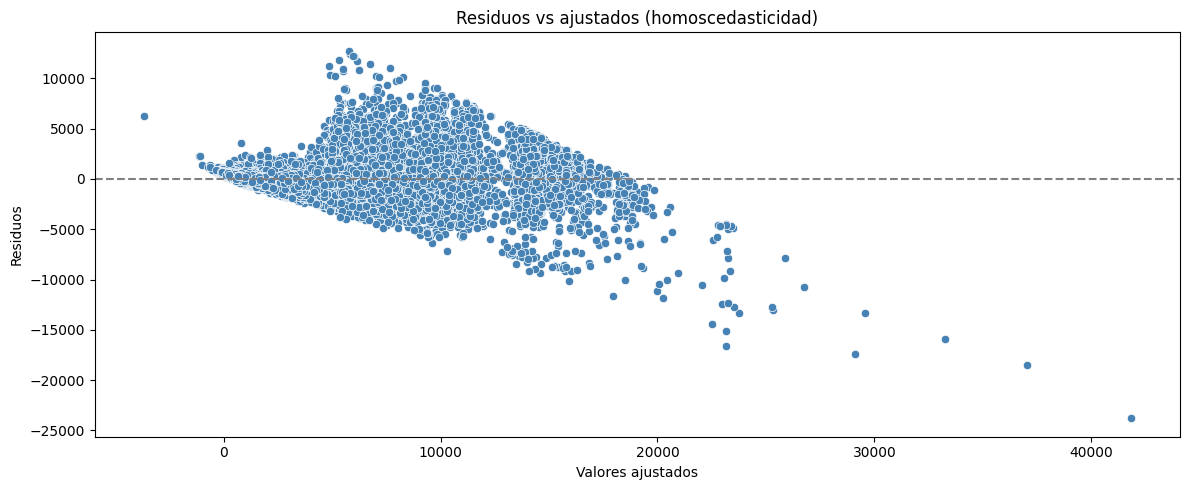

In [63]:
fig, ax = plt.subplots(figsize=(12, 5))

# Homoscedasticidad
sns.scatterplot(x=model.fittedvalues, y=model.resid, ax=ax, color='steelblue')
ax.axhline(0, color='gray', linestyle='--')
ax.set_title("Residuos vs ajustados (homoscedasticidad)")
ax.set_xlabel("Valores ajustados")
ax.set_ylabel("Residuos")

plt.tight_layout()
plt.show()


In [66]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp = het_breuschpagan(model.resid, model.model.exog)

print(" Breusch–Pagan (homoscedasticidad):")
print(f"p-valor: {bp[1]:.4f} → {'No hay evidencia de heterocedasticidad' if bp[1] > 0.05 else 'Posible heterocedasticidad'}")


 Breusch–Pagan (homoscedasticidad):
p-valor: 0.0000 → Posible heterocedasticidad


### Interpretación

**El grafico no muestra embudos, pero parece haber una tendencia a disminuir, por lo que se opta a usar la prueba de Bresuch-Pagan, esta arroja un resultado de cero, por lo que se concluye con que no homocedasticidad sino heterocedasticidad**

### Grafico de comparación entre los valores reales y los valores predichos por el modelo

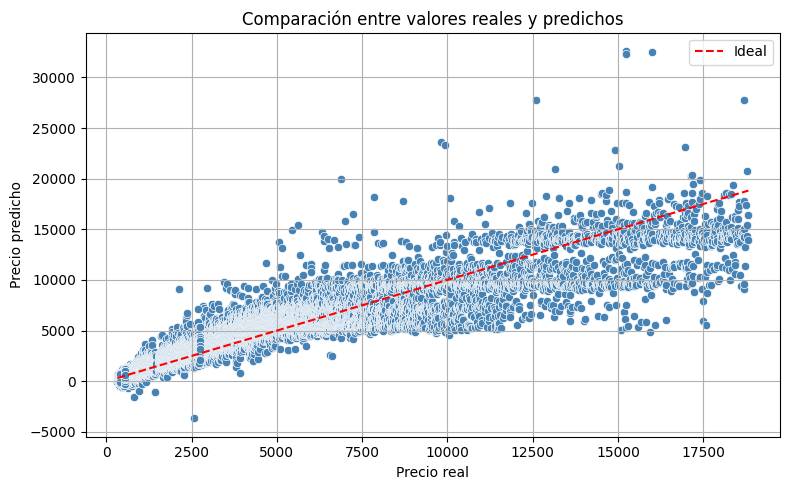

In [59]:
# Gráfico de comparación
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Y, y=pred, color='steelblue')
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], color='red', linestyle='--', label='Ideal')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Comparación entre valores reales y predichos')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()